# BCB Random Forest AST/CPG Eigenvalue-Threshold CV Results

This notebook visualizes the outputs produced by `run_pipeline/02_rf_eigenvalue_threshold_cv.py`.

The RF experiment is intentionally focused on `AST` and `CPG` only. Older outputs from the previous per-variant schema are detected and treated as stale.

In [26]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "spectral_code").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import OUTPUTS_ROOT

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 180)

EXPECTED_GRAPH_TYPES = ["ast", "cpg"]
RUN_COMMAND = "python notebooks/datasets/bigclonebench/run_pipeline/02_rf_eigenvalue_threshold_cv.py"

RESULT_ROOT = OUTPUTS_ROOT / "bcb" / "rf_eigenvalue_threshold_cv"
RESULTS_CSV = RESULT_ROOT / "rf_eigenvalue_threshold_cv_results.csv"
FOLDS_CSV = RESULT_ROOT / "rf_eigenvalue_threshold_cv_folds.csv"
COUNTS_CSV = RESULT_ROOT / "rf_eigenvalue_threshold_partition_counts.csv"
IMPORTANCE_CSV = RESULT_ROOT / "rf_eigenvalue_threshold_feature_importances.csv"
SUMMARY_JSON = RESULT_ROOT / "rf_eigenvalue_threshold_cv_summary.json"

print("Result root:", RESULT_ROOT)
for artifact_path in [RESULTS_CSV, FOLDS_CSV, COUNTS_CSV, IMPORTANCE_CSV, SUMMARY_JSON]:
    print(f"{artifact_path.name}: {artifact_path.exists()} {artifact_path}")
print()
print("Run command for fresh AST/CPG results:")
print(RUN_COMMAND)


Result root: C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv
rf_eigenvalue_threshold_cv_results.csv: True C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv\rf_eigenvalue_threshold_cv_results.csv
rf_eigenvalue_threshold_cv_folds.csv: True C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv\rf_eigenvalue_threshold_cv_folds.csv
rf_eigenvalue_threshold_partition_counts.csv: True C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv\rf_eigenvalue_threshold_partition_counts.csv
rf_eigenvalue_threshold_feature_importances.csv: True C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv\rf_eigenvalue_threshold_feature_importances.csv
rf_eigenvalue_threshold_cv_summary.json: True C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv\rf_eigenvalue_threshold_cv_summary.json

Run command for fresh AST/CPG results:
python notebooks/datasets/bigclonebench/run_pipel

## Load Artifacts

In [27]:
def read_csv_if_present(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size <= 2:
        return pd.DataFrame()
    return pd.read_csv(path)


def graph_list_is_ast_cpg(values) -> bool:
    values = [str(value).strip().lower() for value in (values or []) if str(value).strip()]
    return values == EXPECTED_GRAPH_TYPES


summary = json.loads(SUMMARY_JSON.read_text(encoding="utf-8")) if SUMMARY_JSON.exists() else {}
raw_results_df = read_csv_if_present(RESULTS_CSV)
raw_folds_df = read_csv_if_present(FOLDS_CSV)
raw_counts_df = read_csv_if_present(COUNTS_CSV)
raw_importance_df = read_csv_if_present(IMPORTANCE_CSV)

required_result_columns = {
    "task", "partition", "mode", "graph_type", "threshold", "status", "feature_graphs",
    "feature_rows", "target_counts", "f1_from_oof_predictions",
}
current_schema = required_result_columns.issubset(raw_results_df.columns)
current_summary = summary.get("schema_version") == 2 and graph_list_is_ast_cpg(summary.get("graph_types"))
outputs_are_current = bool(current_schema and current_summary)

artifact_df = pd.DataFrame([
    {"artifact": "results", "rows": len(raw_results_df), "path": str(RESULTS_CSV)},
    {"artifact": "folds", "rows": len(raw_folds_df), "path": str(FOLDS_CSV)},
    {"artifact": "partition_counts", "rows": len(raw_counts_df), "path": str(COUNTS_CSV)},
    {"artifact": "feature_importances", "rows": len(raw_importance_df), "path": str(IMPORTANCE_CSV)},
])
display(artifact_df)

display(pd.DataFrame([
    {"check": "result schema has task/features", "value": current_schema},
    {"check": "summary schema_version == 2", "value": summary.get("schema_version") == 2},
    {"check": "summary graph_types == ast,cpg", "value": graph_list_is_ast_cpg(summary.get("graph_types"))},
    {"check": "outputs usable by this notebook", "value": outputs_are_current},
]))

if summary:
    display(pd.DataFrame([
        {"key": "experiment", "value": summary.get("experiment", "")},
        {"key": "schema_version", "value": summary.get("schema_version", "")},
        {"key": "seconds", "value": summary.get("seconds", "")},
        {"key": "graph_types", "value": ", ".join(map(str, summary.get("graph_types", [])))},
        {"key": "sampling_scheme", "value": summary.get("sampling_scheme", "")},
        {"key": "eigen_threshold", "value": summary.get("eigen_threshold", "")},
        {"key": "graph_filter_mode", "value": summary.get("graph_filter_mode", "")},
        {"key": "type4_ratio", "value": summary.get("type4_ratio", "")},
        {"key": "tasks", "value": ", ".join(map(str, summary.get("tasks", [])))},
        {"key": "thresholds", "value": ", ".join(map(str, summary.get("thresholds", [])))},
        {"key": "partition_modes", "value": ", ".join(map(str, summary.get("partition_modes", [])))},
        {"key": "cv_folds", "value": summary.get("cv_folds", "")},
        {"key": "max_pairs_per_partition", "value": summary.get("max_pairs_per_partition", "")},
    ]))

if not outputs_are_current:
    print("These artifacts are missing or stale for the current AST/CPG RF notebook.")
    if not raw_results_df.empty:
        print("Existing result columns:", list(raw_results_df.columns))
        if "status" in raw_results_df.columns:
            display(raw_results_df.groupby("status", dropna=False).size().reset_index(name="rows"))
            if "reason" in raw_results_df.columns:
                display(raw_results_df[raw_results_df["status"].astype(str) != "ok"].groupby("reason", dropna=False).size().reset_index(name="rows"))
    print()
    print("Rerun this command, then rerun this notebook:")
    print(RUN_COMMAND)

results_df = raw_results_df.copy() if outputs_are_current else pd.DataFrame()
folds_df = raw_folds_df.copy() if outputs_are_current else pd.DataFrame()
counts_df = raw_counts_df.copy() if outputs_are_current else pd.DataFrame()
importance_df = raw_importance_df.copy() if outputs_are_current else pd.DataFrame()


,artifact,rows,path
0,results,2,C:\Users\koush\PyProjects\spectrals\outputs\bc...
1,folds,10,C:\Users\koush\PyProjects\spectrals\outputs\bc...
2,partition_counts,1,C:\Users\koush\PyProjects\spectrals\outputs\bc...
3,feature_importances,220,C:\Users\koush\PyProjects\spectrals\outputs\bc...


,check,value
0,result schema has task/features,True
1,summary schema_version == 2,True
2,"summary graph_types == ast,cpg",True
3,outputs usable by this notebook,True


,key,value
0,experiment,bcb_rf_eigenvalue_threshold_cv
1,schema_version,2
2,seconds,243.311432
3,graph_types,"ast, cpg"
4,sampling_scheme,type123_type4_quarter_balanced
5,eigen_threshold,50
6,graph_filter_mode,all_graphs
7,type4_ratio,0.25
8,tasks,"binary, multiclass"
9,thresholds,50


## Result Overview

In [28]:
if results_df.empty:
    print("No current AST/CPG RF results to display yet.")
else:
    display(results_df.head())
    status_summary = results_df.groupby(["task", "status"], dropna=False).size().reset_index(name="rows")
    display(status_summary)
    skipped = results_df[results_df["status"].astype(str) != "ok"].copy()
    if not skipped.empty:
        display(skipped.groupby(["task", "reason"], dropna=False).size().reset_index(name="rows"))

ok_df = results_df[results_df.get("status", pd.Series(dtype=str)).eq("ok")].copy() if not results_df.empty else pd.DataFrame()
if not ok_df.empty:
    ok_df = ok_df[
        ok_df["feature_graphs"].astype(str).apply(
            lambda value: set(value.split(",")).issubset(set(EXPECTED_GRAPH_TYPES))
        )
    ].copy()

metric_cols = [
    "accuracy_from_oof_predictions",
    "precision_from_oof_predictions",
    "recall_from_oof_predictions",
    "f1_from_oof_predictions",
    "auc_from_oof_predictions",
    "accuracy_fold_mean",
    "precision_fold_mean",
    "recall_fold_mean",
    "f1_fold_mean",
]

if ok_df.empty:
    print("No successful AST/CPG RF partitions are available in the current artifacts.")
else:
    overview_cols = [
        "task", "partition", "mode", "graph_type", "threshold", "feature_graphs",
        "feature_count", "feature_rows", "target_counts",
        *[col for col in metric_cols if col in ok_df.columns],
    ]
    display(ok_df[overview_cols].sort_values("f1_from_oof_predictions", ascending=False).head(40))


,task,partition,mode,graph_type,threshold,feature_graphs,feature_count,status,reason,pairs_before_sampling,pairs_after_sampling,feature_rows,target_counts,skipped_feature_pairs,effective_folds,rows,positive_rows,negative_rows,tp,fp,tn,fn,accuracy_from_oof_predictions,precision_from_oof_predictions,recall_from_oof_predictions,f1_from_oof_predictions,auc_from_oof_predictions,accuracy_fold_mean,accuracy_fold_std,precision_fold_mean,precision_fold_std,recall_fold_mean,recall_fold_std,f1_fold_mean,f1_fold_std,auc_fold_mean,auc_fold_std
0,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,118107,1680,74066,2605,0.978189,0.985975,0.978420,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.978420,0.000823,0.982183,0.000464,0.997158,0.000108
1,multiclass,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{'non_clone': 75746, 'type4': 24142, 'type1': ...",0,5,196458,0,0,0,0,0,0,0.918242,0.832626,0.897409,0.841811,0.989020,0.918242,0.000764,0.832684,0.002212,0.897409,0.001459,0.841828,0.002124,0.989076,0.000511


,task,status,rows
0,binary,ok,1
1,multiclass,ok,1


,task,partition,mode,graph_type,threshold,feature_graphs,feature_count,feature_rows,target_counts,accuracy_from_oof_predictions,precision_from_oof_predictions,recall_from_oof_predictions,f1_from_oof_predictions,auc_from_oof_predictions,accuracy_fold_mean,precision_fold_mean,recall_fold_mean,f1_fold_mean
0,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,196458,"{0: 75746, 1: 120712}",0.978189,0.985975,0.978420,0.982183,0.997158,0.978189,0.985976,0.978420,0.982183
1,multiclass,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,196458,"{'non_clone': 75746, 'type4': 24142, 'type1': ...",0.918242,0.832626,0.897409,0.841811,0.989020,0.918242,0.832684,0.897409,0.841828


## Metric Text Summary


In [29]:
if ok_df.empty:
    print("No successful AST/CPG RF rows to summarize.")
else:
    metric_names = [
        ("accuracy", "accuracy_from_oof_predictions"),
        ("precision", "precision_from_oof_predictions"),
        ("recall", "recall_from_oof_predictions"),
        ("f1", "f1_from_oof_predictions"),
        ("auc", "auc_from_oof_predictions"),
    ]
    for task, group in ok_df.groupby("task"):
        print(f"\n{str(task).upper()} results")
        top = group.sort_values("f1_from_oof_predictions", ascending=False).head(5)
        for row in top.itertuples(index=False):
            values = []
            for label, col in metric_names:
                if col in top.columns:
                    values.append(f"{label}={float(getattr(row, col)):.4f}")
            print(
                f"- {row.partition} | graphs={row.feature_graphs} | threshold={row.threshold}: "
                + ", ".join(values)
            )
    if "auc_from_oof_predictions" in ok_df.columns:
        multiclass_auc = ok_df.loc[ok_df["task"].astype(str).eq("multiclass"), "auc_from_oof_predictions"]
        if not multiclass_auc.empty and np.allclose(multiclass_auc.fillna(0).to_numpy(dtype=float), 0.0):
            print("\nNote: multiclass AUC is zero in these artifacts. Rerun the updated RF script; it now computes macro OVR ROC-AUC for multiclass.")



BINARY results
- type123_plus_type4_0.25_balanced_ge50_all_graphs | graphs=ast,cpg | threshold=50: accuracy=0.9782, precision=0.9860, recall=0.9784, f1=0.9822, auc=0.9972

MULTICLASS results
- type123_plus_type4_0.25_balanced_ge50_all_graphs | graphs=ast,cpg | threshold=50: accuracy=0.9182, precision=0.8326, recall=0.8974, f1=0.8418, auc=0.9890


## Partition Counts

,partition,mode,graph_type,threshold,pairs,positive_pairs,negative_pairs,type123_positive_pairs,type4_positive_pool,type4_positive_target,type4_positive_sampled,non_clone_pool,non_clone_target,non_clone_sampled,class_counts
0,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,196458,120712,75746,96570,683103,24142,24142,75746,120712,75746,"{'non_clone': 75746, 'type4': 24142, 'type1': ..."


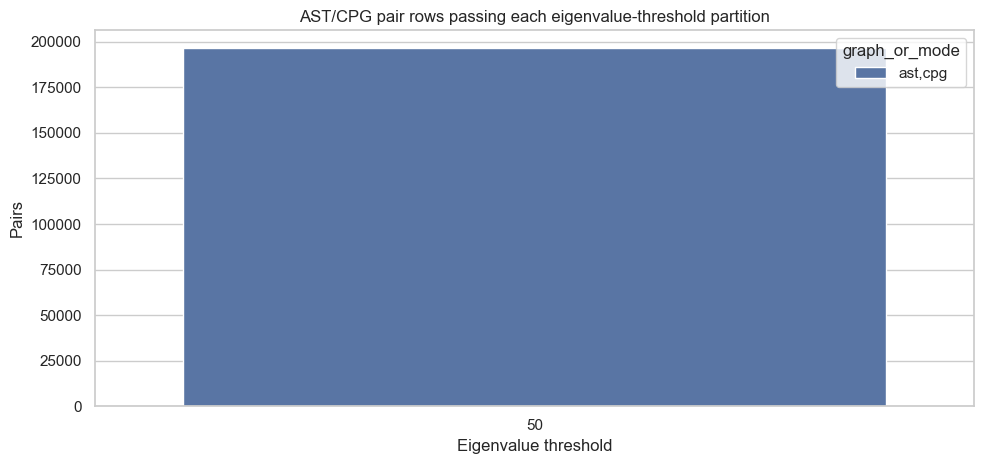

In [30]:
if counts_df.empty:
    print("No current partition-count rows to display.")
else:
    display(counts_df)
    plot_counts = counts_df.copy()
    plot_counts["graph_or_mode"] = np.where(
        plot_counts["graph_type"].fillna("").astype(str).eq(""),
        plot_counts["mode"].astype(str),
        plot_counts["graph_type"].astype(str),
    )
    plt.figure(figsize=(10, 4.8))
    sns.barplot(data=plot_counts, x="threshold", y="pairs", hue="graph_or_mode", errorbar=None)
    plt.title("AST/CPG pair rows passing each eigenvalue-threshold partition")
    plt.xlabel("Eigenvalue threshold")
    plt.ylabel("Pairs")
    plt.tight_layout()
    plt.show()


## Performance Plots

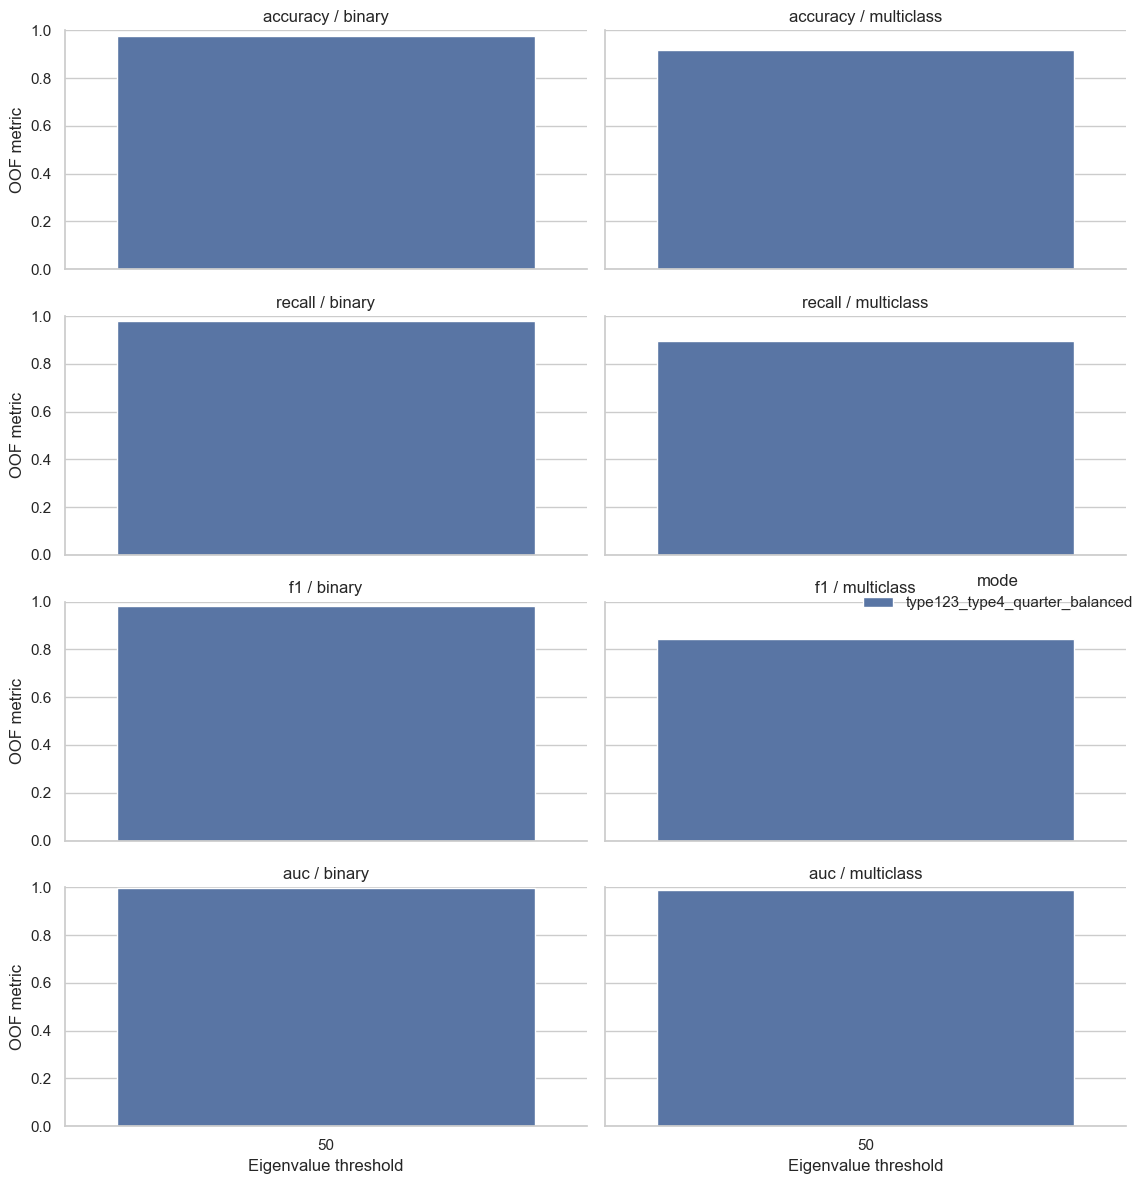

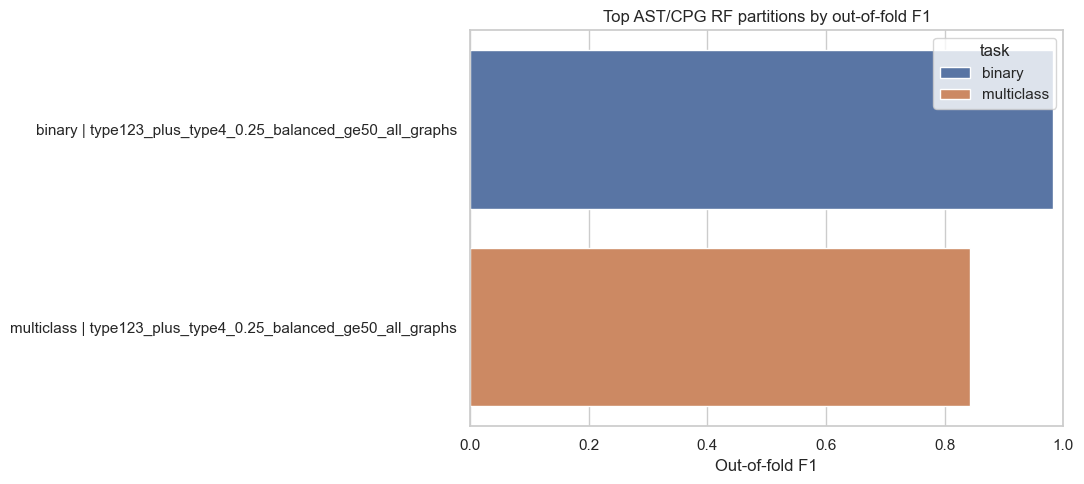

In [31]:
if ok_df.empty:
    print("No successful AST/CPG RF results to plot.")
else:
    if "auc_from_oof_predictions" in ok_df.columns:
        stale_multiclass_auc = ok_df[ok_df["task"].astype(str).eq("multiclass")]["auc_from_oof_predictions"]
        if not stale_multiclass_auc.empty and np.allclose(stale_multiclass_auc.fillna(0).to_numpy(dtype=float), 0.0):
            print("Multiclass AUC is zero in the current artifacts. Rerun the updated RF script to fill macro OVR AUC.")

    perf_long = ok_df.melt(
        id_vars=["task", "partition", "mode", "graph_type", "threshold", "feature_graphs"],
        value_vars=[
            col for col in [
                "accuracy_from_oof_predictions",
                "precision_from_oof_predictions",
                "recall_from_oof_predictions",
                "f1_from_oof_predictions",
                "auc_from_oof_predictions",
            ] if col in ok_df.columns
        ],
        var_name="metric",
        value_name="value",
    )
    perf_long["metric"] = perf_long["metric"].str.replace("_from_oof_predictions", "", regex=False)

    g = sns.catplot(
        data=perf_long[perf_long["metric"].isin(["accuracy", "recall", "f1", "auc"])],
        x="threshold",
        y="value",
        hue="mode",
        col="task",
        row="metric",
        kind="bar",
        errorbar=None,
        height=3.0,
        aspect=1.45,
        sharey=True,
    )
    g.set_axis_labels("Eigenvalue threshold", "OOF metric")
    g.set_titles("{row_name} / {col_name}")
    for ax in g.axes.flat:
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    top_df = ok_df.sort_values("f1_from_oof_predictions", ascending=False).head(25).copy()
    top_df["label"] = top_df["task"].astype(str) + " | " + top_df["partition"].astype(str)
    plt.figure(figsize=(11, max(5, 0.34 * len(top_df))))
    sns.barplot(data=top_df, x="f1_from_oof_predictions", y="label", hue="task", dodge=False)
    plt.xlim(0, 1)
    plt.xlabel("Out-of-fold F1")
    plt.ylabel("")
    plt.title("Top AST/CPG RF partitions by out-of-fold F1")
    plt.tight_layout()
    plt.show()


## Fold-Level Stability

,task,partition,mode,graph_type,threshold,feature_graphs,feature_count,status,reason,pairs_before_sampling,pairs_after_sampling,feature_rows,target_counts,skipped_feature_pairs,effective_folds,rows,positive_rows,negative_rows,tp,fp,tn,fn,accuracy_from_oof_predictions,precision_from_oof_predictions,recall_from_oof_predictions,f1_from_oof_predictions,auc_from_oof_predictions,accuracy_fold_mean,accuracy_fold_std,precision_fold_mean,precision_fold_std,recall_fold_mean,recall_fold_std,f1_fold_mean,f1_fold_std,auc_fold_mean,auc_fold_std,fold,train_rows,test_rows,positive_test_rows,negative_test_rows,accuracy,precision,recall,f1,auc
0,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,23643,372,14778,499,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,1,157166,39292,24142,15150,0.977833,0.984510,0.979331,0.981913,0.997239
1,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,23598,305,14844,545,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,2,157166,39292,24143,15149,0.978367,0.987240,0.977426,0.982309,0.997053
2,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,23636,338,14811,507,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,3,157166,39292,24143,15149,0.978494,0.985901,0.979000,0.982439,0.997119
3,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,23633,318,14831,509,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,4,157167,39291,24142,15149,0.978952,0.986723,0.978916,0.982804,0.997326
4,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,23597,347,14802,545,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,5,157167,39291,24142,15149,0.977298,0.985508,0.977425,0.981450,0.997055


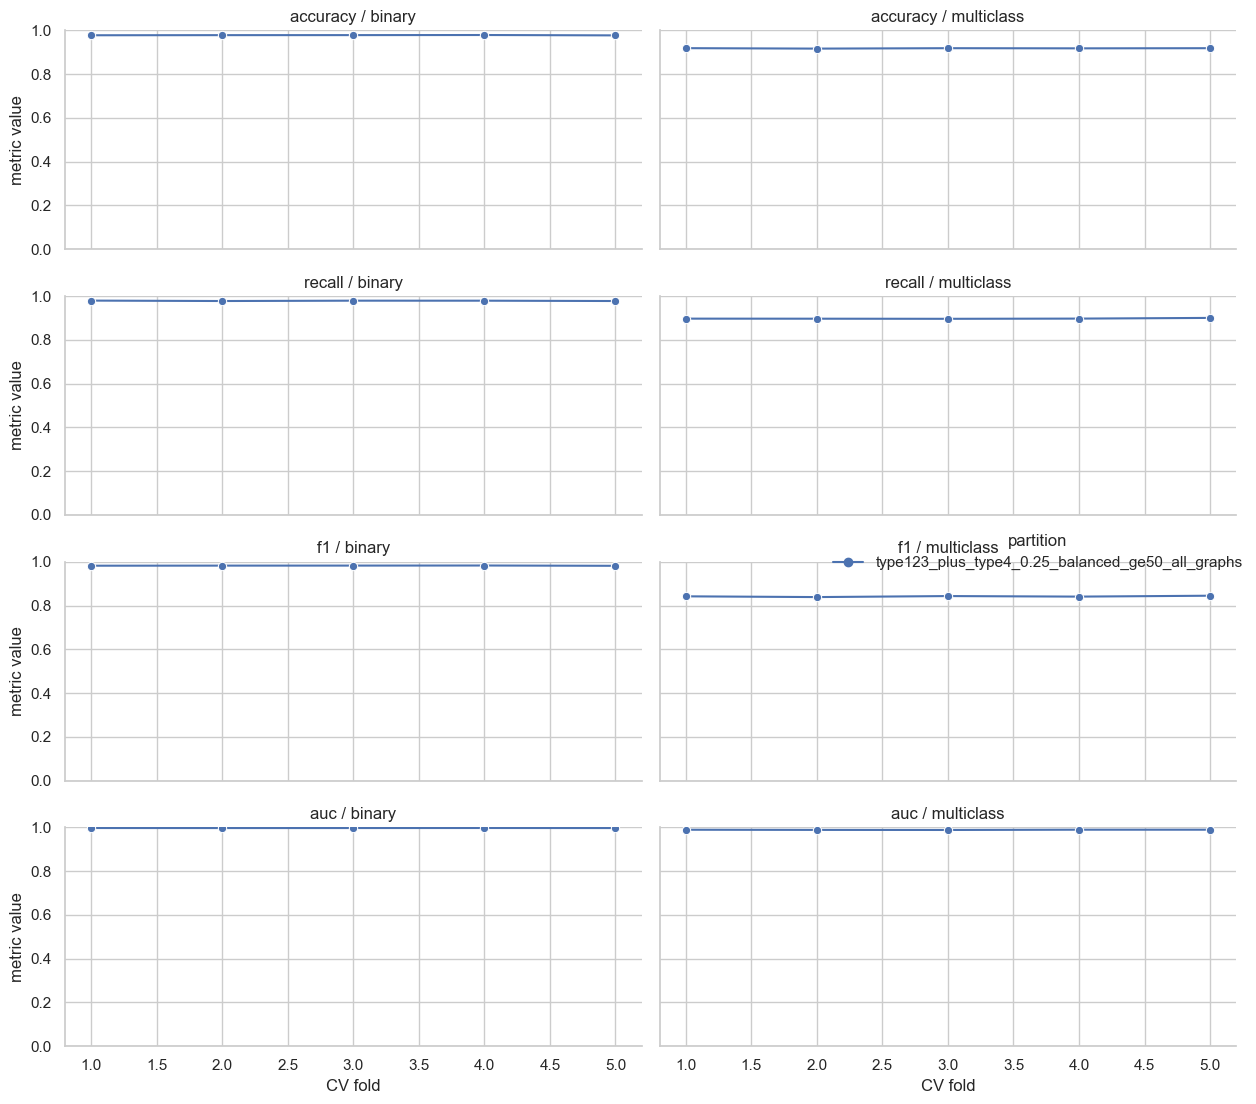

In [32]:
if folds_df.empty:
    print("No current fold-level rows to display.")
else:
    display(folds_df.head())
    fold_metric_cols = [col for col in ["accuracy", "precision", "recall", "f1", "auc"] if col in folds_df.columns]
    fold_long = folds_df.melt(
        id_vars=["task", "partition", "fold", "mode", "graph_type", "threshold"],
        value_vars=fold_metric_cols,
        var_name="metric",
        value_name="value",
    )
    g = sns.relplot(
        data=fold_long[fold_long["metric"].isin(["accuracy", "recall", "f1", "auc"])],
        x="fold",
        y="value",
        hue="partition",
        col="task",
        row="metric",
        kind="line",
        marker="o",
        height=2.8,
        aspect=1.5,
        facet_kws={"sharey": True},
    )
    g.set_axis_labels("CV fold", "metric value")
    g.set_titles("{row_name} / {col_name}")
    for ax in g.axes.flat:
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


## Binary Confusion Matrix

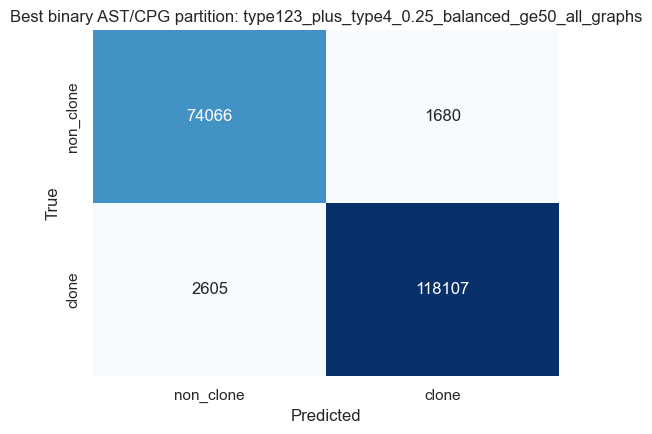

,value
task,binary
partition,type123_plus_type4_0.25_balanced_ge50_all_graphs
mode,type123_type4_quarter_balanced
graph_type,"ast,cpg"
threshold,50
feature_graphs,"ast,cpg"
feature_count,22
status,ok
reason,NaN
pairs_before_sampling,196458


In [33]:
binary_ok = ok_df[ok_df["task"].astype(str).eq("binary")].copy() if not ok_df.empty else pd.DataFrame()
if binary_ok.empty:
    print("No successful binary AST/CPG RF row found.")
else:
    best_binary = binary_ok.sort_values("f1_from_oof_predictions", ascending=False).iloc[0]
    cm = np.array([
        [int(best_binary.get("tn", 0)), int(best_binary.get("fp", 0))],
        [int(best_binary.get("fn", 0)), int(best_binary.get("tp", 0))],
    ])
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["non_clone", "clone"], yticklabels=["non_clone", "clone"], cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Best binary AST/CPG partition: {best_binary['partition']}")
    plt.tight_layout()
    plt.show()
    display(best_binary.to_frame("value"))


## Feature Importances

,task,partition,mode,graph_type,threshold,feature_graphs,feature_count,status,reason,pairs_before_sampling,pairs_after_sampling,feature_rows,target_counts,skipped_feature_pairs,effective_folds,rows,positive_rows,negative_rows,tp,fp,tn,fn,accuracy_from_oof_predictions,precision_from_oof_predictions,recall_from_oof_predictions,f1_from_oof_predictions,auc_from_oof_predictions,accuracy_fold_mean,accuracy_fold_std,precision_fold_mean,precision_fold_std,recall_fold_mean,recall_fold_std,f1_fold_mean,f1_fold_std,auc_fold_mean,auc_fold_std,fold,feature,importance
0,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,118107,1680,74066,2605,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,1,ast_pss,0.044485
1,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,118107,1680,74066,2605,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,1,ast_wasserstein,0.068144
2,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,118107,1680,74066,2605,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,1,ast_left_count,0.019754
3,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,118107,1680,74066,2605,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,1,ast_right_count,0.113048
4,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,type123_type4_quarter_balanced,"ast,cpg",50,"ast,cpg",22,ok,NaN,196458,196458,196458,"{0: 75746, 1: 120712}",0,5,196458,120712,75746,118107,1680,74066,2605,0.978189,0.985975,0.97842,0.982183,0.997158,0.978189,0.000571,0.985976,0.000952,0.97842,0.000823,0.982183,0.000464,0.997158,0.000108,1,ast_min_count,0.056072


,task,feature,mean_importance,std_importance
4,binary,ast_mean_abs_diff,0.104330,0.008126
7,binary,ast_right_count,0.103557,0.005626
18,binary,cpg_right_count,0.101909,0.003822
15,binary,cpg_mean_abs_diff,0.087252,0.009319
40,multiclass,cpg_right_count,0.082050,0.005108
29,multiclass,ast_right_count,0.079585,0.004279
10,binary,ast_wasserstein,0.073148,0.006164
43,multiclass,cpg_wasserstein,0.063651,0.009277
2,binary,ast_max_abs_diff,0.063509,0.007276
6,binary,ast_pss,0.061191,0.017950


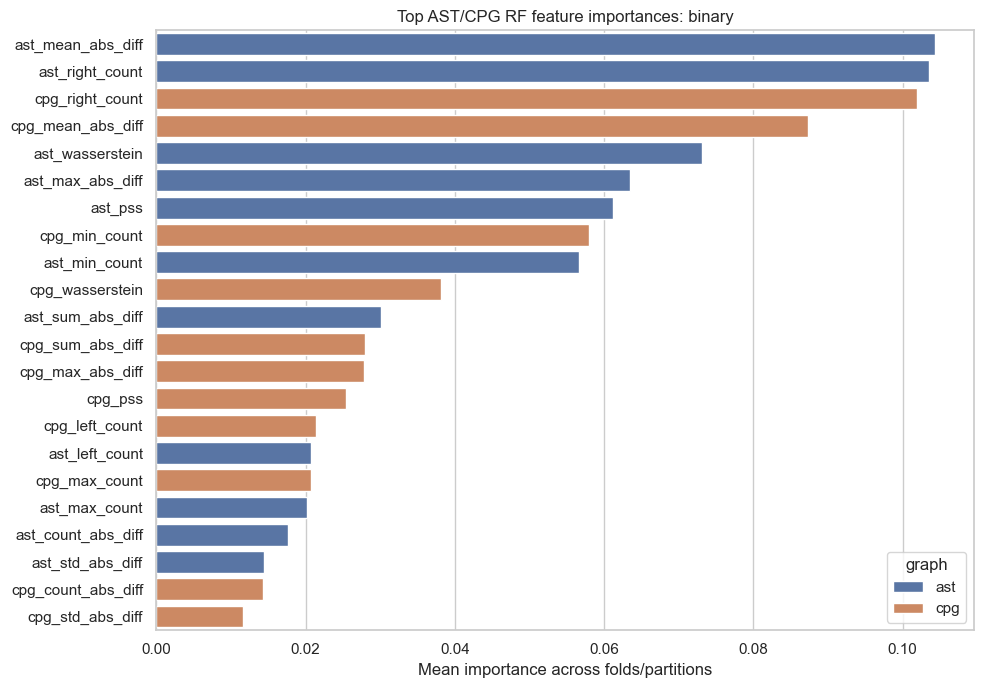

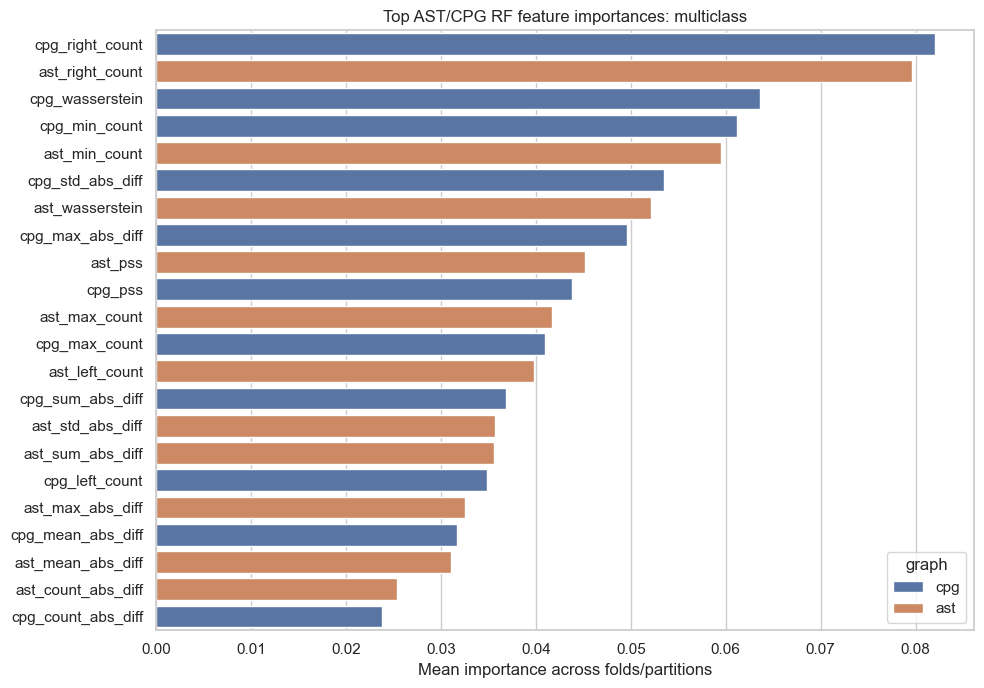

,task,partition,feature,mean_importance
4,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,ast_mean_abs_diff,0.104330
7,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,ast_right_count,0.103557
18,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,cpg_right_count,0.101909
15,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,cpg_mean_abs_diff,0.087252
10,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,ast_wasserstein,0.073148
2,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,ast_max_abs_diff,0.063509
6,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,ast_pss,0.061191
16,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,cpg_min_count,0.057934
5,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,ast_min_count,0.056669
21,binary,type123_plus_type4_0.25_balanced_ge50_all_graphs,cpg_wasserstein,0.038146


In [34]:
if importance_df.empty:
    print("No current feature-importance rows found. Rerun the AST/CPG RF script first if the artifacts are stale.")
else:
    importance_df = importance_df[importance_df["feature"].astype(str).str.startswith(("ast_", "cpg_"))].copy()
    display(importance_df.head())
    importance_summary = (
        importance_df
        .groupby(["task", "feature"], as_index=False)
        .agg(mean_importance=("importance", "mean"), std_importance=("importance", "std"))
        .sort_values("mean_importance", ascending=False)
    )
    display(importance_summary.head(40))

    for task, group in importance_summary.groupby("task"):
        top = group.head(25)
        plt.figure(figsize=(10, max(4.5, 0.32 * len(top))))
        sns.barplot(data=top, x="mean_importance", y="feature", hue=top["feature"].str.split("_").str[0], dodge=False)
        plt.xlabel("Mean importance across folds/partitions")
        plt.ylabel("")
        plt.title(f"Top AST/CPG RF feature importances: {task}")
        plt.legend(title="graph")
        plt.tight_layout()
        plt.show()

    if not ok_df.empty:
        best_rows = ok_df.sort_values("f1_from_oof_predictions", ascending=False).groupby("task").head(1)[["task", "partition"]]
        best_importance = importance_df.merge(best_rows, on=["task", "partition"], how="inner")
        best_importance_summary = (
            best_importance.groupby(["task", "partition", "feature"], as_index=False)
            .agg(mean_importance=("importance", "mean"))
            .sort_values(["task", "mean_importance"], ascending=[True, False])
        )
        display(best_importance_summary.groupby("task").head(20))


## Exportable Accuracy Summary Image


,Task,Dataset / Partition,Graphs,Threshold,Rows,Accuracy,Precision,Recall,F1,AUC
0,BINARY,balanced ge50,"AST,CPG",50,"196,458",0.9782,0.9860,0.9784,0.9822,0.9972
1,MULTICLASS,balanced ge50,"AST,CPG",50,"196,458",0.9182,0.8326,0.8974,0.8418,0.9890


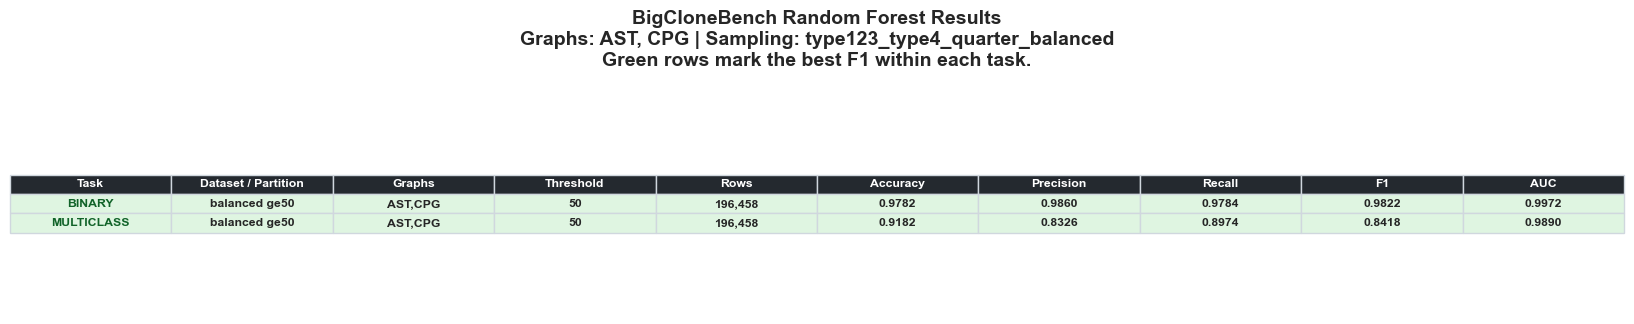

Saved summary image: C:\Users\koush\PyProjects\spectrals\outputs\bcb\rf_eigenvalue_threshold_cv\rf_accuracy_summary_table.png


In [35]:
SUMMARY_IMAGE_PATH = RESULT_ROOT / "rf_accuracy_summary_table.png"


def _format_metric(value) -> str:
    if pd.isna(value):
        return "-"
    return f"{float(value):.4f}"


def _compact_partition(value: str) -> str:
    value = str(value)
    value = value.replace("type123_plus_type4_0.25_balanced_ge50_all_graphs", "balanced ge50")
    value = value.replace("type123_plus_type4_0.25_balanced_ge50_any_shared_graph", "balanced any ge50")
    return value


if ok_df.empty:
    print("No successful RF rows are available yet. Run the RF script, then rerun this notebook.")
else:
    summary_cols = [
        "task", "partition", "feature_graphs", "threshold", "feature_rows",
        "accuracy_from_oof_predictions", "precision_from_oof_predictions",
        "recall_from_oof_predictions", "f1_from_oof_predictions", "auc_from_oof_predictions",
    ]
    available_cols = [col for col in summary_cols if col in ok_df.columns]
    export_df = ok_df[available_cols].copy()
    export_df = export_df.sort_values(["task", "f1_from_oof_predictions", "accuracy_from_oof_predictions"], ascending=[True, False, False]).reset_index(drop=True)

    best_by_task = set(export_df.groupby("task")["f1_from_oof_predictions"].idxmax().dropna().astype(int).tolist()) if "f1_from_oof_predictions" in export_df.columns else set()

    display_df = pd.DataFrame({
        "Task": export_df.get("task", pd.Series(dtype=str)).astype(str).str.upper(),
        "Dataset / Partition": export_df.get("partition", pd.Series(dtype=str)).map(_compact_partition),
        "Graphs": export_df.get("feature_graphs", pd.Series(dtype=str)).astype(str).str.upper(),
        "Threshold": export_df.get("threshold", pd.Series(dtype=float)).map(lambda value: f"{int(value)}" if pd.notna(value) else "-"),
        "Rows": export_df.get("feature_rows", pd.Series(dtype=float)).map(lambda value: f"{int(value):,}" if pd.notna(value) else "-"),
        "Accuracy": export_df.get("accuracy_from_oof_predictions", pd.Series(dtype=float)).map(_format_metric),
        "Precision": export_df.get("precision_from_oof_predictions", pd.Series(dtype=float)).map(_format_metric),
        "Recall": export_df.get("recall_from_oof_predictions", pd.Series(dtype=float)).map(_format_metric),
        "F1": export_df.get("f1_from_oof_predictions", pd.Series(dtype=float)).map(_format_metric),
        "AUC": export_df.get("auc_from_oof_predictions", pd.Series(dtype=float)).map(_format_metric),
    })
    display(display_df)

    fig_height = max(3.4, 0.48 * len(display_df) + 1.8)
    fig, ax = plt.subplots(figsize=(16.5, fig_height))
    ax.axis("off")
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        loc="center",
        cellLoc="center",
        colLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.8 if len(display_df) <= 18 else 7.6)
    table.scale(1.0, 1.38)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#D0D7DE")
        if row == 0:
            cell.set_facecolor("#24292F")
            cell.get_text().set_color("white")
            cell.get_text().set_weight("bold")
            continue

        source_idx = row - 1
        task_name = str(export_df.iloc[source_idx].get("task", "")) if source_idx < len(export_df) else ""
        is_best = source_idx in best_by_task
        if is_best:
            cell.set_facecolor("#DFF5E1")
            cell.get_text().set_weight("bold")
            if col == 0:
                cell.get_text().set_color("#116329")
        elif task_name == "binary":
            cell.set_facecolor("#F5FAFF" if row % 2 else "#EEF6FF")
        elif task_name == "multiclass":
            cell.set_facecolor("#FBF7FF" if row % 2 else "#F4ECFF")
        elif row % 2 == 0:
            cell.set_facecolor("#F6F8FA")
        else:
            cell.set_facecolor("white")

    graph_text = ", ".join(map(str, summary.get("graph_types", EXPECTED_GRAPH_TYPES))) if isinstance(summary, dict) else ", ".join(EXPECTED_GRAPH_TYPES)
    scheme_text = summary.get("sampling_scheme", "") if isinstance(summary, dict) else ""
    subtitle = f"Graphs: {graph_text.upper()}"
    if scheme_text:
        subtitle += f" | Sampling: {scheme_text}"

    ax.set_title(
        "BigCloneBench Random Forest Results\n" + subtitle + "\nGreen rows mark the best F1 within each task.",
        fontsize=14,
        weight="bold",
        pad=20,
    )
    plt.tight_layout()
    RESULT_ROOT.mkdir(parents=True, exist_ok=True)
    fig.savefig(SUMMARY_IMAGE_PATH, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved summary image: {SUMMARY_IMAGE_PATH}")
